In [2]:
from all_imports import *

In [4]:
# 1. Filter delivered orders and calculate actual transit time (Purchase -> Delivery)
delivered_geo = orders_df[orders_df['order_status'] == 'delivered'].copy()
delivered_geo.dropna(subset=['order_delivered_customer_date', 'order_purchase_timestamp'], inplace=True)

delivered_geo['order_purchase_timestamp'] = pd.to_datetime(delivered_geo['order_purchase_timestamp'])
delivered_geo['order_delivered_customer_date'] = pd.to_datetime(delivered_geo['order_delivered_customer_date'])

delivered_geo['transit_days'] = (
    delivered_geo['order_delivered_customer_date'] - 
    delivered_geo['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)

# 2. Aggregate financials and get seller_id per order
# (Summing freight/price for multi-item orders, and taking the first seller_id)
order_financials = orderItems_df.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    seller_id=('seller_id', 'first') 
).reset_index()

# 3. Merge Orders, Financials, Customers, and Sellers
geo_master = delivered_geo[['order_id', 'customer_id', 'transit_days']].merge(
    order_financials, on='order_id', how='inner'
).merge(
    customers_df[['customer_id', 'customer_state']], on='customer_id', how='left'
).merge(
    sellers_df[['seller_id', 'seller_state']], on='seller_id', how='left'
)

# 4. Create Geographic Routing Features
geo_master['route'] = geo_master['seller_state'] + " → " + geo_master['customer_state']
geo_master['is_interstate'] = geo_master['seller_state'] != geo_master['customer_state']
geo_master['freight_ratio'] = geo_master['total_freight'] / geo_master['total_price']

# 5. Attach Review Scores
order_reviews_agg = orderReviews_df.groupby('order_id')['review_score'].mean().reset_index()
geo_master = geo_master.merge(order_reviews_agg, on='order_id', how='left')
geo_master.dropna(subset=['review_score'], inplace=True)

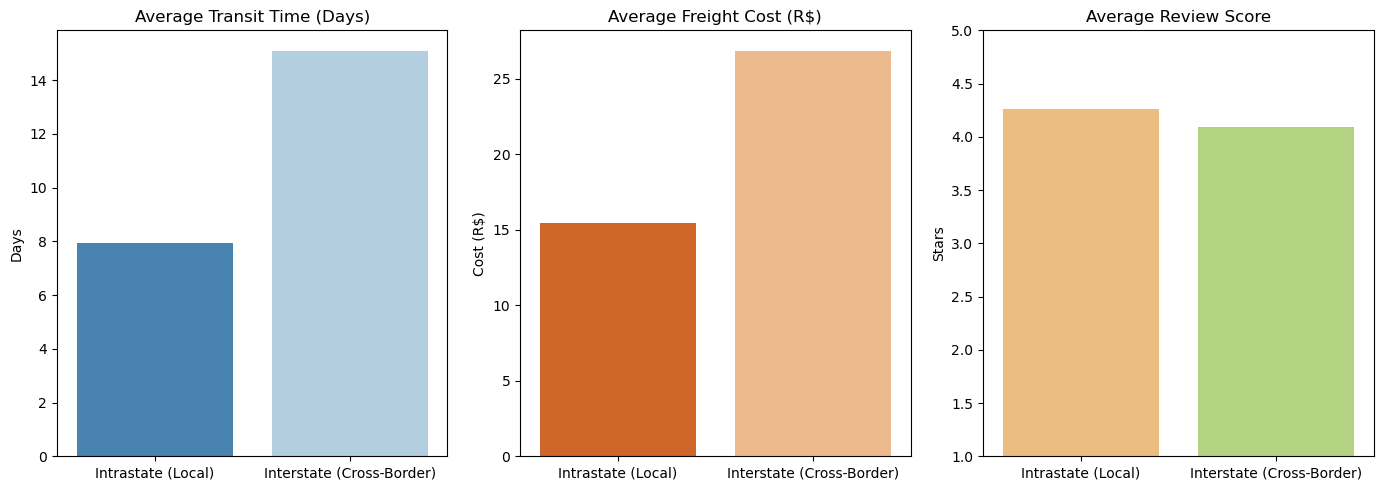

In [9]:
plt.figure(figsize=(14, 5))

# Group by Interstate vs Intrastate
interstate_stats = geo_master.groupby('is_interstate').agg(
    avg_transit=('transit_days', 'mean'),
    avg_freight=('total_freight', 'mean'),
    avg_score=('review_score', 'mean')
).reset_index()
interstate_stats['is_interstate'] = interstate_stats['is_interstate'].replace({True: 'Interstate (Cross-Border)', False: 'Intrastate (Local)'})

# Plot 1: Transit Time
plt.subplot(1, 3, 1)
sns.barplot(data=interstate_stats, x='is_interstate', y='avg_transit', hue='is_interstate', palette='Blues_r', legend=False)
plt.title('Average Transit Time (Days)')
plt.ylabel('Days')
plt.xlabel('')

# Plot 2: Freight Cost
plt.subplot(1, 3, 2)
sns.barplot(data=interstate_stats, x='is_interstate', y='avg_freight', hue='is_interstate', palette='Oranges_r', legend=False)
plt.title('Average Freight Cost (R$)')
plt.ylabel('Cost (R$)')
plt.xlabel('')

# Plot 3: Review Score
plt.subplot(1, 3, 3)
sns.barplot(data=interstate_stats, x='is_interstate', y='avg_score', hue='is_interstate', palette='RdYlGn', legend=False)
plt.title('Average Review Score')
plt.ylim(1, 5)
plt.ylabel('Stars')
plt.xlabel('')

plt.tight_layout()
plt.show()

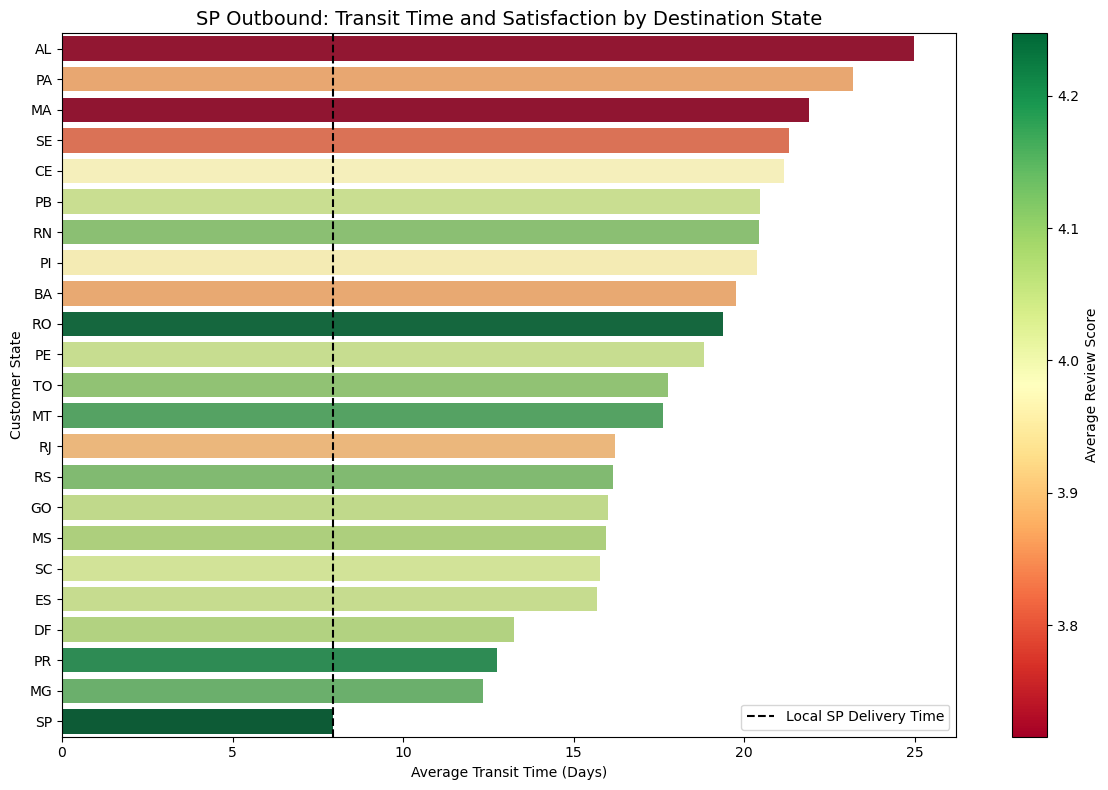

In [6]:
# Filter for orders originating from SP (the massive majority)
sp_outbound = geo_master[geo_master['seller_state'] == 'SP']

# Calculate metrics by destination state
sp_routes = sp_outbound.groupby('customer_state').agg(
    order_volume=('order_id', 'count'),
    avg_transit=('transit_days', 'mean'),
    avg_score=('review_score', 'mean')
).reset_index()

# Filter out states with tiny volume for a cleaner chart, sort by transit time
sp_routes = sp_routes[sp_routes['order_volume'] > 100].sort_values('avg_transit', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=sp_routes, 
    x='avg_transit', 
    y='customer_state', 
    hue='avg_score', 
    palette='RdYlGn', 
    dodge=False,
    legend=False # Using colormap instead
)

# Add a colorbar to explain the hue mapping
norm = plt.Normalize(sp_routes['avg_score'].min(), sp_routes['avg_score'].max())
sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical')
cbar.set_label('Average Review Score')

plt.axvline(sp_routes[sp_routes['customer_state'] == 'SP']['avg_transit'].values[0], color='black', linestyle='--', label='Local SP Delivery Time')
plt.title('SP Outbound: Transit Time and Satisfaction by Destination State', fontsize=14)
plt.xlabel('Average Transit Time (Days)')
plt.ylabel('Customer State')
plt.legend()
plt.tight_layout()
plt.show()

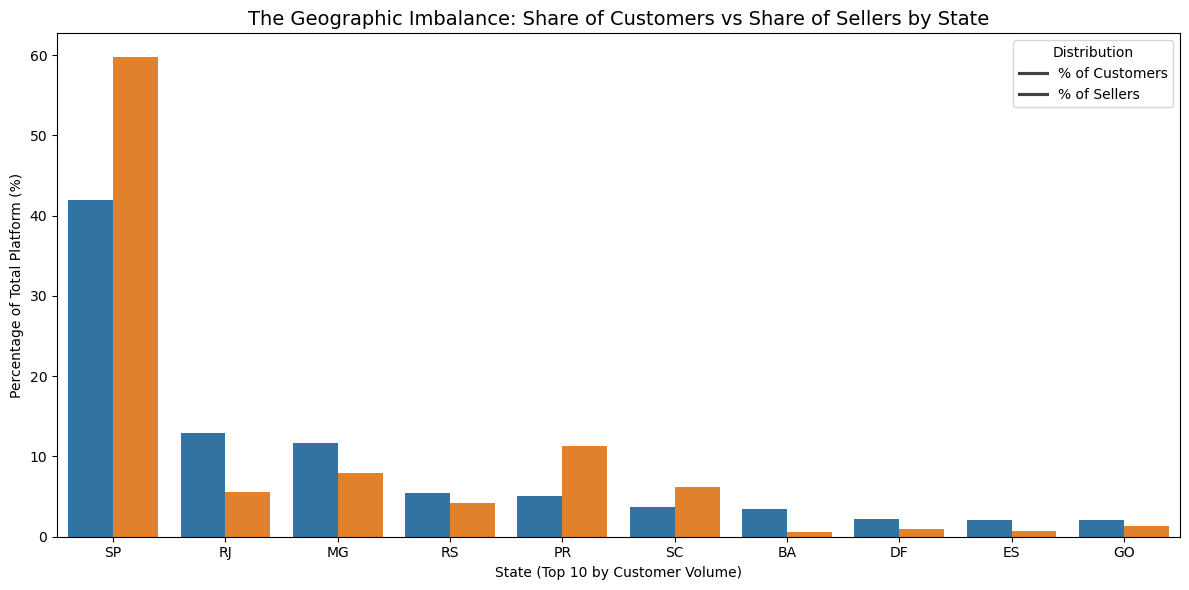

In [7]:
# Calculate % of total sellers and % of total customers per state
seller_dist = sellers_df['seller_state'].value_counts(normalize=True).reset_index()
seller_dist.columns = ['state', 'seller_pct']
seller_dist['seller_pct'] *= 100

customer_dist = customers_df['customer_state'].value_counts(normalize=True).reset_index()
customer_dist.columns = ['state', 'customer_pct']
customer_dist['customer_pct'] *= 100

# Merge distributions and filter to top 10 states by customer demand
supply_demand = pd.merge(customer_dist, seller_dist, on='state', how='left').fillna(0)
top_10_states = supply_demand.head(10).melt(id_vars='state', var_name='type', value_name='percentage')

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_states, 
    x='state', 
    y='percentage', 
    hue='type', 
    palette={'customer_pct': '#1f77b4', 'seller_pct': '#ff7f0e'}
)

plt.title('The Geographic Imbalance: Share of Customers vs Share of Sellers by State', fontsize=14)
plt.xlabel('State (Top 10 by Customer Volume)')
plt.ylabel('Percentage of Total Platform (%)')
plt.legend(title='Distribution', labels=['% of Customers', '% of Sellers'])
plt.tight_layout()
plt.show()